In [1]:
# CELL 1: Imports
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# CELL 2: Load the CSV file
FILE_PATH = r"C:\Users\admin\Downloads\classData.csv"

try:
    df = pd.read_csv(FILE_PATH)
    print(f"Loaded '{FILE_PATH}' successfully. Shape: {df.shape}")
    print("Columns found:", df.columns.tolist())
except FileNotFoundError:
    raise SystemExit(f"ERROR: File not found at '{FILE_PATH}'. Please check the path.")
except Exception as e:
    raise SystemExit(f"ERROR: Could not read CSV file. Details: {e}")

Loaded 'C:\Users\admin\Downloads\classData.csv' successfully. Shape: (7861, 10)
Columns found: ['G', 'C', 'B', 'A', 'Ia', 'Ib', 'Ic', 'Va', 'Vb', 'Vc']


In [3]:
# CELL 3: Decide x-axis — 'Time' column if present, else row index
if 'Time' in df.columns:
    x_axis = df['Time']
    x_label = 'Time'
    print("Using 'Time' column as x-axis.")
else:
    x_axis = df.index
    x_label = 'Sample Index'
    print("No 'Time' column found. Using row index as x-axis instead.")

No 'Time' column found. Using row index as x-axis instead.


In [4]:
# CELL 4: Helper function — plot three-phase voltage (with optional zoom)
def plot_three_phase_voltage(ax, x, data, title, x_range=None):
    voltage_cols = ['Va', 'Vb', 'Vc']
    available_cols = [col for col in voltage_cols if col in data.columns]
    missing_cols = [col for col in voltage_cols if col not in data.columns]

    if not available_cols:
        ax.text(0.5, 0.5, "Voltage columns (Va, Vb, Vc) not found in CSV",
                 ha='center', va='center', transform=ax.transAxes, fontsize=10, color='red')
        ax.set_title(title)
        return

    if missing_cols:
        print(f"Warning: Missing voltage column(s) for '{title}': {missing_cols}")

    colors = {'Va': 'red', 'Vb': 'green', 'Vc': 'blue'}

    if x_range is not None:
        x_plot = x[x_range]
        for col in available_cols:
            ax.plot(x_plot, data[col].iloc[x_range], label=col, color=colors[col], linewidth=1)
    else:
        for col in available_cols:
            ax.plot(x, data[col], label=col, color=colors[col], linewidth=1)

    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Voltage')
    ax.legend()
    ax.grid(True)

In [5]:
# CELL 5: Helper function — plot a single current signal (Ia / Ib)
def plot_single_signal(ax, x, data, column_name, title, color):
    if column_name not in data.columns:
        ax.text(0.5, 0.5, f"Column '{column_name}' not found in CSV",
                 ha='center', va='center', transform=ax.transAxes, fontsize=10, color='red')
        ax.set_title(title)
        return

    ax.plot(x, data[column_name], label=column_name, color=color, linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(x_label)
    ax.set_ylabel('Current')
    ax.legend()
    ax.grid(True)

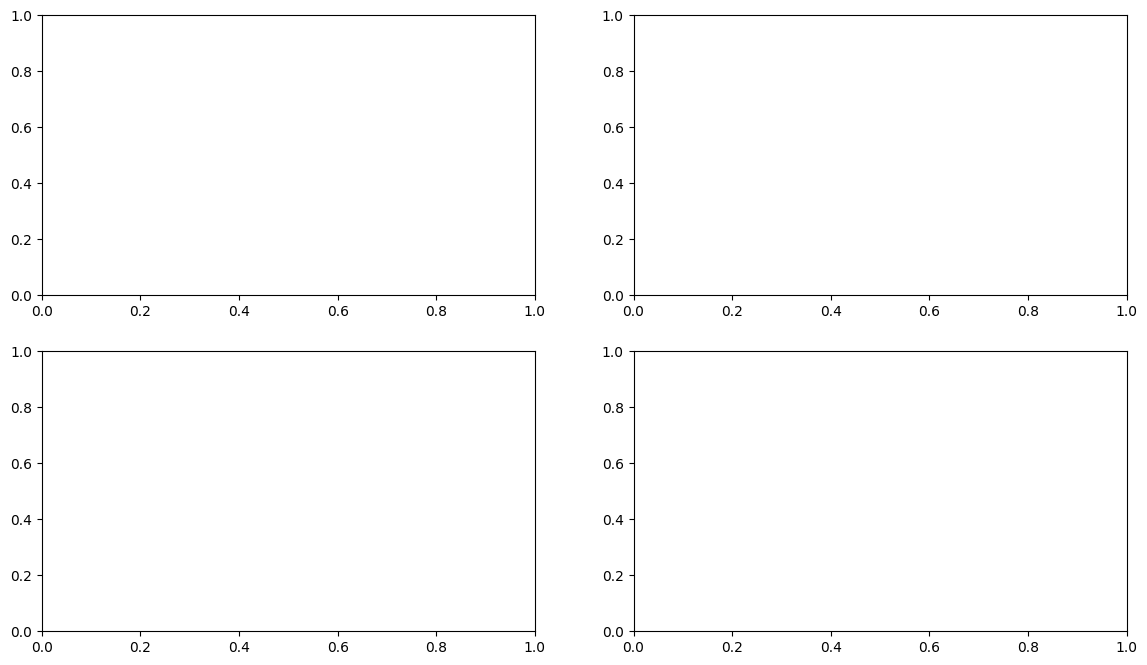

In [6]:
# CELL 6: Create the 2x2 subplot grid
fig, axes = plt.subplots(2, 2, figsize=(14, 8))

In [8]:
# CELL 7: Subplot 1 — Three Phase Voltage (full range) & Subplot 2 — Ia
plot_three_phase_voltage(axes[0, 0], x_axis, df, 'Three Phase Voltage')
plot_single_signal(axes[0, 1], x_axis, df, 'Ia', 'Ia', color='purple')